# Downloading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Imports

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("<path_to_file>/survey_results_public.csv")
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


# What is the relationship between preferred online learning resources (e.g., Stack Overflow, blogs, AI tools) and the type of developer role respondents currently have?

In [ ]:
columns_list = df.columns.to_list()
print(columns_list)

['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith',

In [ ]:
other_specify_responses = df[df['LearnCodeOnline'].str.contains('Other', na=False)]['LearnCodeOnline']
print(other_specify_responses)

39       Technical documentation;Blogs;Books;Written Tu...
62       Stack Overflow;Social Media;Interactive tutori...
83       Technical documentation;Blogs;Written Tutorial...
328      Blogs;Written Tutorials;Stack Overflow;Social ...
345      Technical documentation;Blogs;Stack Overflow;C...
                               ...                        
64828    Technical documentation;Blogs;Written Tutorial...
65170                              Other (Please specify):
65288    Technical documentation;Stack Overflow;How-to ...
65316    Technical documentation;Blogs;Written Tutorial...
65399    Technical documentation;Blogs;Books;Written Tu...
Name: LearnCodeOnline, Length: 840, dtype: object


In [ ]:
def recategorize_learn_code(learn_code):
    if isinstance(learn_code, str) and 'Other' in learn_code:
        specified = learn_code.split(';')[-1].strip().lower() # Assuming "Other..." is the first part
        if 'stack overflow' in specified:
            return learn_code.replace('Other online resources (e.g., videos, blogs, forums)', 'Stack Overflow')
        elif 'medium' in specified or 'dev.to' in specified:
            return learn_code.replace('Other online resources (e.g., videos, blogs, forums)', 'Blogs')
        elif 'youtube' in specified or 'coursera' in specified:
            return learn_code.replace('Other online resources (e.g., videos, blogs, forums)', 'Online Courses')
        elif 'ai' in specified or 'chatgpt' in specified:
            return learn_code.replace('Other online resources (e.g., videos, blogs, forums)', 'AI tools')
        elif 'discord' in specified or 'slack' in specified:
            return learn_code.replace('Other online resources (e.g., videos, blogs, forums)', 'Online Communities')
        else:
            return learn_code.replace('Other online resources (e.g., videos, blogs, forums)', f'Other (Specified): {specified}')
    return learn_code

df['LearnCodeOnline_Recategorized'] = df['LearnCodeOnline'].apply(recategorize_learn_code)

print("\n'LearnCode' column after recategorization:")
print(df['LearnCodeOnline_Recategorized'].value_counts().head(20))


'LearnCode' column after recategorization:
LearnCodeOnline_Recategorized
Technical documentation;Blogs;Written Tutorials;Stack Overflow                                                                                                                                                                                                                                                                                              603
Technical documentation;Blogs;Books;Written Tutorials;Stack Overflow                                                                                                                                                                                                                                                                                        505
Technical documentation;Written Tutorials;Stack Overflow                                                                                                                                                                      

In [ ]:
analysis = df[['LearnCodeOnline','DevType']]
print(analysis)

                                         LearnCodeOnline  \
0                                                    NaN   
1      Technical documentation;Blogs;Books;Written Tu...   
2      Technical documentation;Blogs;Books;Written Tu...   
3      Stack Overflow;How-to videos;Interactive tutorial   
4      Technical documentation;Blogs;Written Tutorial...   
...                                                  ...   
65432                                                NaN   
65433                                                NaN   
65434  Technical documentation;Stack Overflow;Social ...   
65435  Technical documentation;Blogs;Written Tutorial...   
65436                                                NaN   

                     DevType  
0                        NaN  
1      Developer, full-stack  
2       Developer Experience  
3      Developer, full-stack  
4      Developer, full-stack  
...                      ...  
65432             Blockchain  
65433                    NaN  


In [ ]:
analysis = analysis.dropna() # Dropping any data that has NaN
print(analysis.head())
print("Number of rows: " + str(len(analysis)))

                                     LearnCodeOnline                DevType
1  Technical documentation;Blogs;Books;Written Tu...  Developer, full-stack
2  Technical documentation;Blogs;Books;Written Tu...   Developer Experience
3  Stack Overflow;How-to videos;Interactive tutorial  Developer, full-stack
4  Technical documentation;Blogs;Written Tutorial...  Developer, full-stack
6  Technical documentation;Stack Overflow;Written...    Academic researcher
Number of rows: 48504


In [ ]:
# Assuming your DataFrame is 'df' from the previous steps

# 1. Filter rows where 'DevType' contains 'developer'
developer_df = analysis[analysis['DevType'].str.contains('developer,', case=False, na=False)].copy()

print("DataFrame after filtering for 'developer' in DevType:")
print(developer_df[['DevType', 'LearnCodeOnline']].head())

# 2. Function to process each row and create new rows for multiple DevTypes
def restructure_developer_data(row):
    dev_types = [dt.strip() for dt in str(row['DevType']).split(';') if 'developer,' in dt.lower()]
    data = []
    for dt in dev_types:
        data.append({'DevType': dt, 'LearnCodeOnline': row['LearnCodeOnline']})
    return pd.DataFrame(data)

# 3. Apply the function to each row and concatenate the results
restructured_list = []
for index, row in developer_df.iterrows():
    restructured_df = restructure_developer_data(row)
    restructured_list.append(restructured_df)

final_developer_df = pd.concat(restructured_list, ignore_index=True)
final_developer_df['DevType'] = final_developer_df['DevType'].str.replace('Developer,', '', case=False).str.strip()

print("\nRestructured DataFrame:")
print(final_developer_df.head())
print("\nValue Counts of the new 'DevType' column:")
print(final_developer_df['DevType'].value_counts())
analysis = final_developer_df

DataFrame after filtering for 'developer' in DevType:
                 DevType                                    LearnCodeOnline
0  Developer, full-stack  Technical documentation;Blogs;Books;Written Tu...
1  Developer, full-stack  Stack Overflow;How-to videos;Interactive tutorial
2  Developer, full-stack  Technical documentation;Blogs;Written Tutorial...
3  Developer, full-stack  Technical documentation;Blogs;Written Tutorial...
4  Developer, full-stack  Technical documentation;Books;Written Tutorial...

Restructured DataFrame:
      DevType                                    LearnCodeOnline
0  full-stack  Technical documentation;Blogs;Books;Written Tu...
1  full-stack  Stack Overflow;How-to videos;Interactive tutorial
2  full-stack  Technical documentation;Blogs;Written Tutorial...
3  full-stack  Technical documentation;Blogs;Written Tutorial...
4  full-stack  Technical documentation;Books;Written Tutorial...

Value Counts of the new 'DevType' column:
DevType
full-stack              

In [ ]:
# Split the 'LearnCode' strings into lists of individual resources
analysis['LearnCodeOnline_List'] = analysis['LearnCodeOnline'].apply(lambda x: [item.strip() for item in x.split(';')] if isinstance(x, str) else [x])

# Explode the DataFrame to have one row per learning resource for each respondent
analysis_exploded = analysis.explode('LearnCodeOnline_List')
analysis_exploded.rename(columns={'LearnCodeOnline_List': 'OnlineLearningResource'}, inplace=True)

print("\nProcessed DataFrame (exploded - online):")
print(analysis_exploded.head())
print("\nValue Counts for Individual Online Learning Resources:")
print(analysis_exploded['OnlineLearningResource'].value_counts().head(10))


Processed DataFrame (exploded - online):
      DevType                                    LearnCodeOnline  \
0  full-stack  Technical documentation;Blogs;Books;Written Tu...   
0  full-stack  Technical documentation;Blogs;Books;Written Tu...   
0  full-stack  Technical documentation;Blogs;Books;Written Tu...   
0  full-stack  Technical documentation;Blogs;Books;Written Tu...   
0  full-stack  Technical documentation;Blogs;Books;Written Tu...   

    OnlineLearningResource  
0  Technical documentation  
0                    Blogs  
0                    Books  
0        Written Tutorials  
0           Stack Overflow  

Value Counts for Individual Online Learning Resources:
OnlineLearningResource
Technical documentation         27284
Stack Overflow                  25831
Written Tutorials               21981
Blogs                           20297
How-to videos                   17615
Video-based Online Courses      16724
Books                           14913
Social Media                  

In [ ]:
analysis_exploded['DevType'].value_counts()

,count
DevType,
full-stack,101946
back-end,52220
front-end,18381
desktop or enterprise applications,13019
mobile,11094
embedded applications or devices,7723
game or graphics,3763
AI,2907
QA or test,2827


# EDA


Cross-tabulation of Top Online Learning Resources vs. Top Developer Roles:
DevType                        AI  QA or test  back-end  \
OnlineLearningResource                                    
AI                            236         153      2802   
Blogs                         270         209      5120   
Books                         198         183      4235   
How-to videos                 232         251      3943   
Social Media                  171         170      3065   
Stack Overflow                326         334      6229   
Technical documentation       324         329      6756   
Video-based Online Courses    212         252      3931   
Written Tutorials             277         258      5488   
Written-based Online Courses  155         162      2697   

DevType                       desktop or enterprise applications  \
OnlineLearningResource                                             
AI                                                           561   
Blogs      

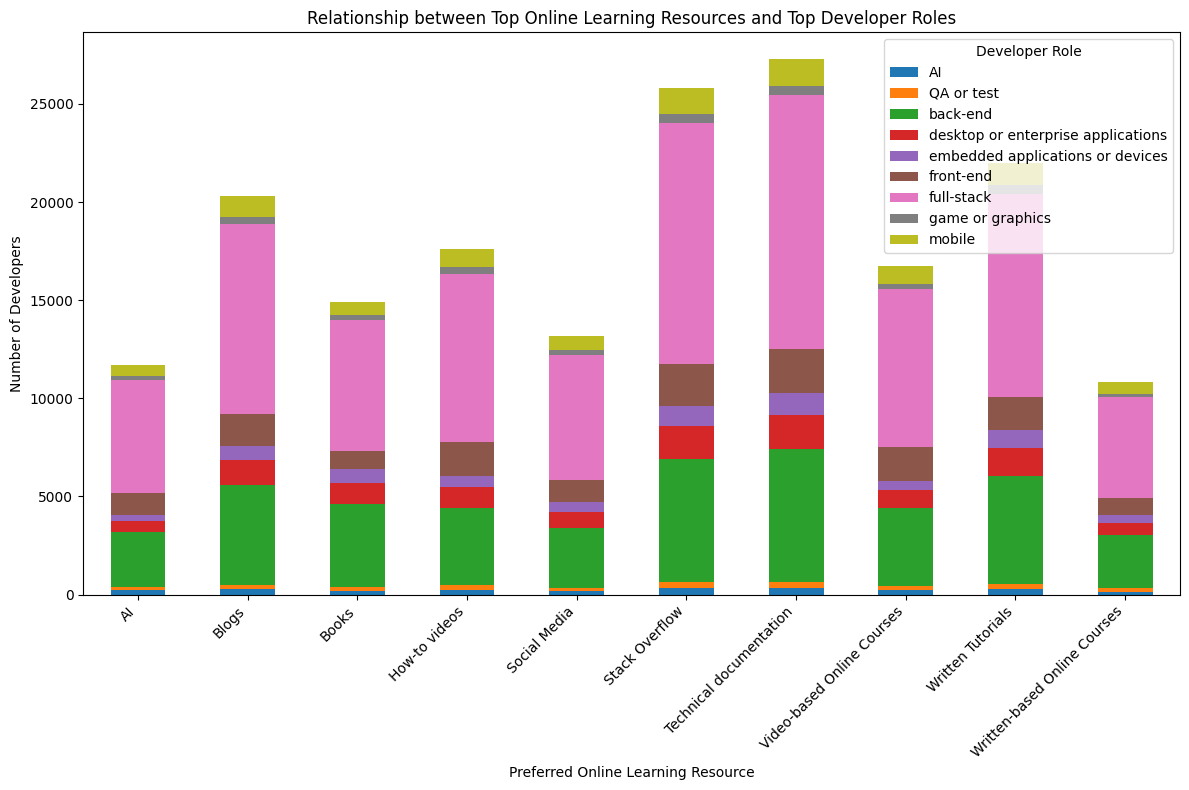

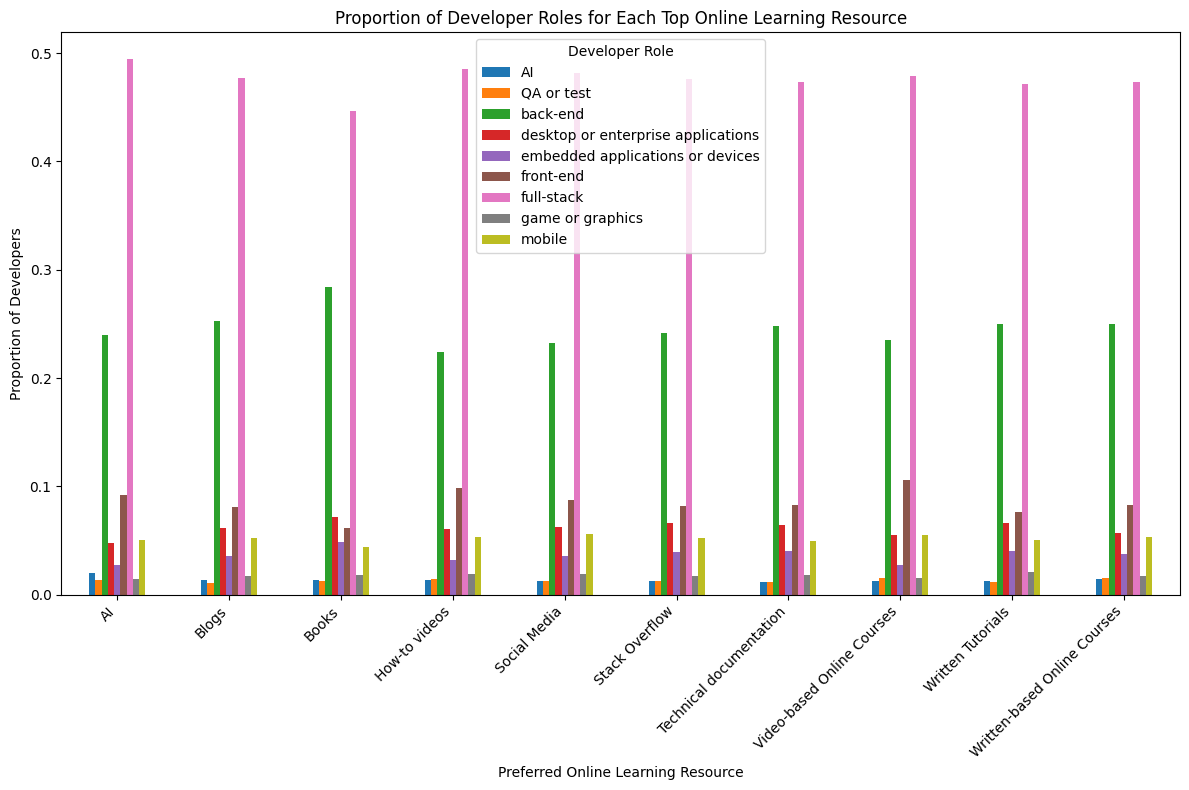

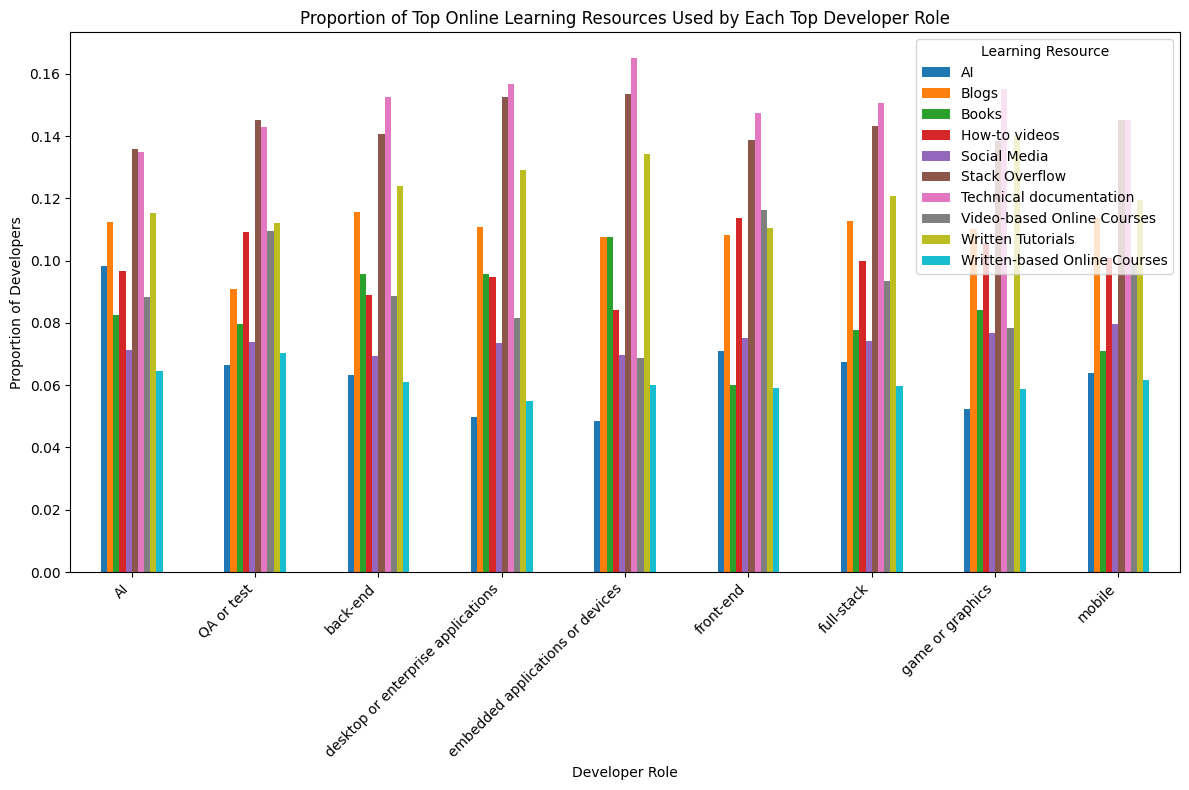

In [ ]:
# Changing the variables
df_analysis = analysis_exploded

# Get the top N learning resources and developer roles for better visualization
top_n_resources = df_analysis['OnlineLearningResource'].value_counts().nlargest(10).index
top_n_roles = df_analysis['DevType'].value_counts().nlargest(10).index

df_top_resources_roles = df_analysis[df_analysis['OnlineLearningResource'].isin(top_n_resources) &
                                     df_analysis['DevType'].isin(top_n_roles)]

# Create a cross-tabulation to see the counts of each role for each resource
cross_tab = pd.crosstab(df_top_resources_roles['OnlineLearningResource'], df_top_resources_roles['DevType'])

print("\nCross-tabulation of Top Online Learning Resources vs. Top Developer Roles:")
print(cross_tab)

# Visualize this relationship using a stacked bar chart
cross_tab.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Relationship between Top Online Learning Resources and Top Developer Roles')
plt.xlabel('Preferred Online Learning Resource')
plt.ylabel('Number of Developers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Developer Role')
plt.tight_layout()
plt.show()

# Visualize using a grouped bar chart (normalized to see proportions)
cross_tab_normalized = cross_tab.apply(lambda x: x / x.sum(), axis=1)
cross_tab_normalized.plot(kind='bar', figsize=(12, 8))
plt.title('Proportion of Developer Roles for Each Top Online Learning Resource')
plt.xlabel('Preferred Online Learning Resource')
plt.ylabel('Proportion of Developers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Developer Role')
plt.tight_layout()
plt.show()

# Further analysis: Proportion of developers using specific online resources within each role
cross_tab_roles = pd.crosstab(df_top_resources_roles['DevType'], df_top_resources_roles['OnlineLearningResource'])
cross_tab_roles_normalized = cross_tab_roles.apply(lambda x: x / x.sum(), axis=1)
cross_tab_roles_normalized.plot(kind='bar', figsize=(12, 8))
plt.title('Proportion of Top Online Learning Resources Used by Each Top Developer Role')
plt.xlabel('Developer Role')
plt.ylabel('Proportion of Developers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Learning Resource')
plt.tight_layout()
plt.show()

# Statistical Test

In [ ]:
# Create the contingency table
contingency_table = pd.crosstab(df_top_resources_roles['OnlineLearningResource'], df_top_resources_roles['DevType'])

print("Contingency Table:")
print(contingency_table)

Contingency Table:
DevType                        AI  QA or test  back-end  \
OnlineLearningResource                                    
AI                            236         153      2802   
Blogs                         270         209      5120   
Books                         198         183      4235   
How-to videos                 232         251      3943   
Social Media                  171         170      3065   
Stack Overflow                326         334      6229   
Technical documentation       324         329      6756   
Video-based Online Courses    212         252      3931   
Written Tutorials             277         258      5488   
Written-based Online Courses  155         162      2697   

DevType                       desktop or enterprise applications  \
OnlineLearningResource                                             
AI                                                           561   
Blogs                                                       1243   


In [ ]:
excel_df = contingency_table.to_excel('contingency_table.xlsx') # for getting the xlsx data in table creation in microsoft word
df.to_excel('./content', engine='xlsxwriter')

In [ ]:
from scipy.stats import chi2_contingency

# Perform the Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-squared Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)
expected_frequencies_table = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
excel_df = expected_frequencies_table.to_excel('frequency_table.xlsx')
df.to_excel('./content', engine='xlsxwriter')

# Interpret the results
alpha = 0.05
print("\nInterpretation:")
if p < alpha:
    print(f"The p-value ({p:.3f}) is less than the significance level ({alpha}).")
    print("We reject the null hypothesis.")
    print("There is a statistically significant association between the preferred online learning resources and the type of developer role.")
else:
    print(f"The p-value ({p:.3f}) is greater than or equal to the significance level ({alpha}).")
    print("We fail to reject the null hypothesis.")
    print("There is no statistically significant association between the preferred online learning resources and the type of developer role based on this data.")


Chi-squared Statistic: 834.6431012583531
P-value: 3.1603691361542597e-130
Degrees of Freedom: 72

Interpretation:
The p-value (0.000) is less than the significance level (0.05).
We reject the null hypothesis.
There is a statistically significant association between the preferred online learning resources and the type of developer role.
